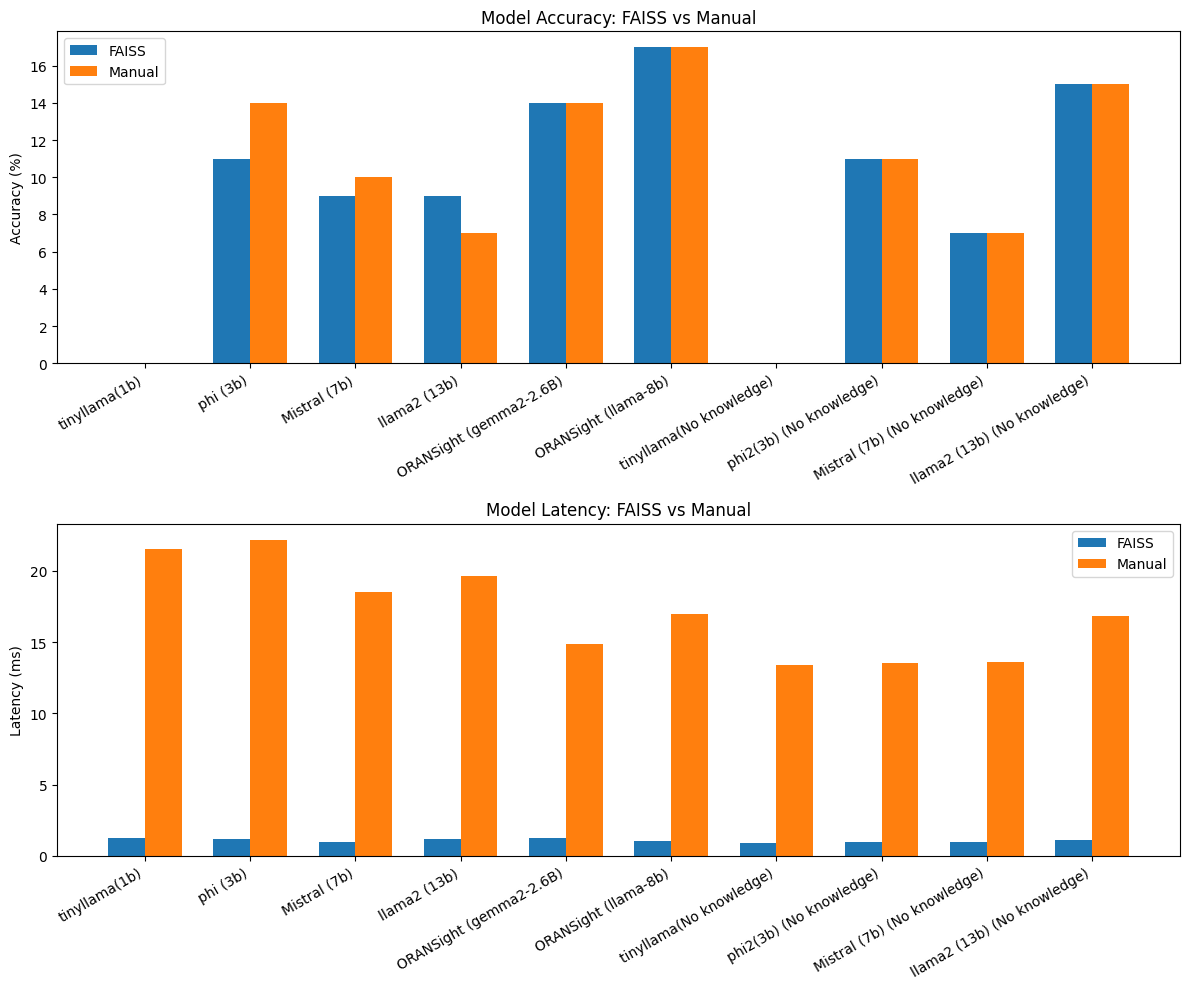

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the data from the CSV file
# Ensure the file name matches your local file
df = pd.read_csv('results.csv')

# Use the exact column names from your table
title_col = 'Title'
acc_faiss = 'Accuracy (FAISS) (%)'
acc_manual = 'Accuracy (Manual) (%)'
lat_faiss = 'Latency (FAISS) (ms)'
lat_manual = 'Latency (Manual) ms'

# Plotting
models = df[title_col]
x = np.arange(len(models))
width = 0.35

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Accuracy Comparison
ax1.bar(x - width/2, df[acc_faiss], width, label='FAISS', color='#1f77b4')
ax1.bar(x + width/2, df[acc_manual], width, label='Manual', color='#ff7f0e')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Model Accuracy: FAISS vs Manual')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=30, ha='right')
ax1.legend()

# Plot 2: Latency Comparison
ax2.bar(x - width/2, df[lat_faiss], width, label='FAISS', color='#1f77b4')
ax2.bar(x + width/2, df[lat_manual], width, label='Manual', color='#ff7f0e')
ax2.set_ylabel('Latency (ms)')
ax2.set_title('Model Latency: FAISS vs Manual')
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=30, ha='right')
ax2.legend()

plt.savefig('accuracy_latency_comparison.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

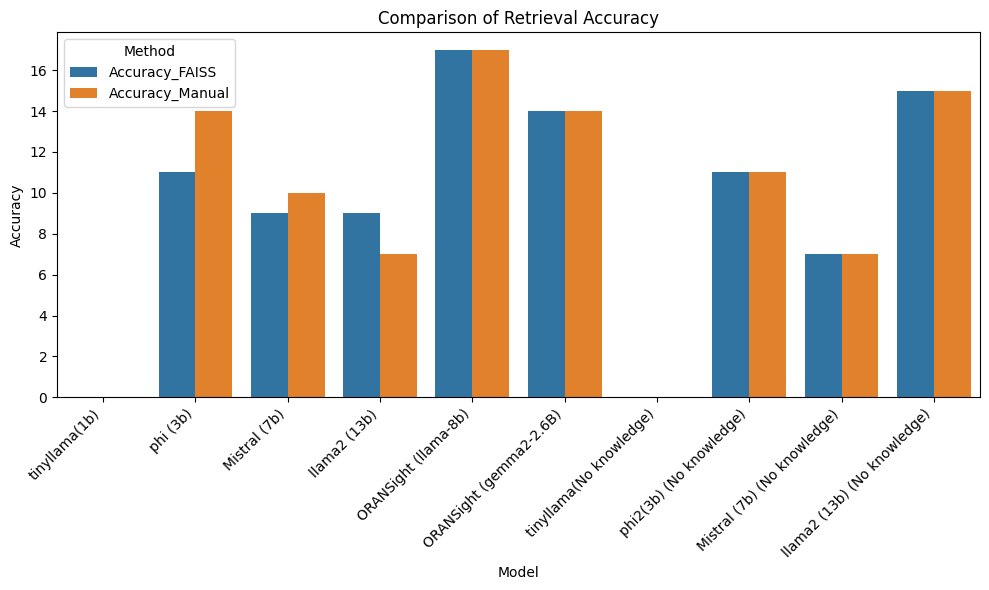

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('results.csv')

# Automatically rename columns for easier handling (The Alternative)
df.columns = [
    'Model', 
    'Latency_FAISS', 'Accuracy_FAISS', 
    'Latency_Manual', 'Accuracy_Manual'
]

# Melt for the accuracy chart
df_acc = df.melt(id_vars='Model', value_vars=['Accuracy_FAISS', 'Accuracy_Manual'], 
                 var_name='Method', value_name='Accuracy')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_acc, x='Model', y='Accuracy', hue='Method')
plt.title('Comparison of Retrieval Accuracy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()